In [1]:
from tavily import TavilyClient

from typing import Literal
from dotenv import load_dotenv
import os
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [2]:
api_key = os.getenv("TAVILY_API_KEY")

In [3]:

client = TavilyClient(api_key=api_key)
def web_search(query:str,topic:Literal["news","general"] = "general",include_raw_data : bool = False):
    "Search through the web for content"
    return client.search(query=query, topic=topic, include_raw_content= include_raw_data)

In [4]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature= 0.5,
)

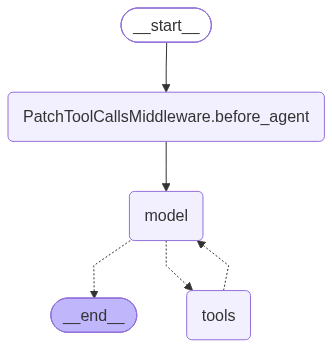

In [5]:
from deepagents import create_deep_agent

deepagent = create_deep_agent(
    model = model,
    tools=[web_search],
    system_prompt= "You are a researcher",
)
deepagent

In [6]:
result = deepagent.invoke({"messages":[{"role":"user","content":"What is the best TTS and STT provider for indian languages?"}]})

In [7]:
result['messages'][-1].content


'Based on the search results, the best TTS and STT provider for Indian languages is Sarvam AI. It offers a range of features, including speech-to-text, text-to-speech, and language models, and supports over 10 Indian languages. It also has a high level of accuracy and can handle background noise and regional accents. Additionally, it has a user-friendly interface and is easy to integrate with other applications.'

In [8]:
result

{'messages': [HumanMessage(content='What is the best TTS and STT provider for indian languages?', additional_kwargs={}, response_metadata={}, id='d4932190-1e09-4259-a45d-d20470ec975b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jaag8b99w', 'function': {'arguments': '{"query":"best TTS and STT provider for Indian languages","topic":"general"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 3317, 'total_tokens': 3347, 'completion_time': 0.103717624, 'completion_tokens_details': None, 'prompt_time': 0.253158071, 'prompt_tokens_details': None, 'queue_time': 0.051620187, 'total_time': 0.356875695}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fda54-3bab-7be0-934e-d04ece295354-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'best T